# Figure S9c–g — Lateral inhibition by PSI-IhNs

Does subtype-selective presynaptic inhibition come from a sensory neuron inhibiting
*itself* (feedback), or from inhibition spread across *other* afferents of the same subtype
(lateral inhibition)?

For every **PSI-IhN ↔ sensory neuron pair**, two fractions are computed:

- **incoming** — of all sensory synapses onto that PSI-IhN's dendrite, what fraction comes
  from this one sensory neuron;
- **outgoing** — of all axoaxonic synapses made by that PSI-IhN's axon, what fraction lands
  back on the same sensory neuron.

Each pair is drawn as a line joining its incoming and outgoing value. If PSI were
self-feedback, pairs would sit high on both axes. They don't: every pair is a small
fraction of both, which is the evidence for lateral inhibition.

**Pair selection.** Only pairs with a real **PSI-IhN axon → sensory neuron** connection are
included (Methods, *Lateral inhibition analysis*). The pairing is therefore anchored on the
axoaxonic output; if that sensory neuron makes no synapse back onto the PSI-IhN dendrite,
its incoming fraction is recorded as 0 rather than the pair being dropped.

| Panel | PSI-IhN population | Sensory subtype |
| --- | --- | --- |
| **c** | Islet-PSI-IhN^C-LTMR | C-LTMR |
| **d** | Islet-PSI-IhN^C-HTMR/Heat | C-HTMR/Heat (MrgprD/A3/B4) |
| **e** | Islet-PSI-IhN^Aδ-LTMR | Aδ-LTMR |
| **f** | PSI-IhN^Aδ-HTMR | Aδ-HTMR |
| **g** | PSI-IhN^Aβ-LTMR | Aβ-LTMR |

**Input.** Four pre-extracted connectivity tables in `../data/lateral_inhibition/`, so the
notebook **runs offline — no CAVE access**. Panels a and b are schematics.


In [1]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "svg.fonttype": "none",
    "font.size": 6,
})
CM = 1 / 2.54


In [2]:
from pathlib import Path

import pandas as pd

DATA = Path("../data/lateral_inhibition")

# nodes.csv            : reconstructed neurons -> subtype tag and position
# edges_all.csv        : synapse counts between reconstructed neurons (used for the
#                        sensory -> PSI-IhN dendrite direction)
# edges_axoaxonic.csv  : synapse counts for PSI-IhN axon -> sensory axon (axoaxonic)
# psi_ihn_axon_dendrite.csv : one row per PSI-IhN, giving the root ID of its axon and
#                        dendrite compartments and the total sensory input onto the dendrite
nodes = pd.read_csv(DATA / "nodes.csv").rename(
    columns={"tag": "cell_type", "pt_root_id": "root_id"})
edges = pd.read_csv(DATA / "edges_all.csv").rename(
    columns={"pre_pt_root_id": "pre_root_id", "post_pt_root_id": "post_root_id"})
edges_aa = pd.read_csv(DATA / "edges_axoaxonic.csv").rename(
    columns={"pre_pt_root_id": "pre_root_id", "post_pt_root_id": "post_root_id"})
psi_ihn = pd.read_csv(DATA / "psi_ihn_axon_dendrite.csv").rename(
    columns={"tag": "cell_type"})

# The node table uses the raw CAVE tags; collapse them to the short names used here.
TAG_RENAME = {
    "mrgd ": "mrgd", "sst ": "sst", "C-COLD": "ccold",
    "ad-htmr": "adhtmr", "c-htmr-p": "chtmr-p", "ab-ltmr": "abltmr",
    "islet-chtmr": "islet-mrgd", "IN for adhtmr": "islet-adhtmr",
    "IN for abltmr": "islet-abltmr", "IN for vertical cell": "islet-V",
}
nodes["cell_type"] = nodes["cell_type"].replace(TAG_RENAME)

# attach the postsynaptic subtype to the axoaxonic edges
edges_aa = edges_aa.merge(
    nodes[["root_id", "cell_type"]].rename(
        columns={"root_id": "post_root_id", "cell_type": "post_cell_type"}),
    on="post_root_id", how="left")

print(f"nodes {len(nodes)}, edges {len(edges)}, axoaxonic edges {len(edges_aa)}, "
      f"PSI-IhNs {len(psi_ihn)}")
print(psi_ihn.cell_type.value_counts().to_string())


nodes 425, edges 10225, axoaxonic edges 2967, PSI-IhNs 28
cell_type
islet-abltmr    7
islet-adhtmr    6
islet-mrgd      5
islet-cltmr     5
islet-adltmr    5


In [3]:
def lateral_pairs(ihn_type, sensory_type):
    """Incoming / outgoing fraction for every PSI-IhN <-> sensory neuron pair.

    Anchored on the axoaxonic connection: iterate the sensory neurons that this
    PSI-IhN's axon synapses onto, then look up how much that same sensory neuron
    contributes to the PSI-IhN's dendritic input (0 if it makes no such synapse).
    """
    outgoing, incoming = [], []

    for _, ihn in psi_ihn[psi_ihn.cell_type == ihn_type].iterrows():
        # every axoaxonic target of this PSI-IhN axon that is of the chosen subtype
        targets = edges_aa[(edges_aa.pre_root_id == ihn.axon_root_id)
                           & (edges_aa.post_cell_type.fillna("") == sensory_type)]
        total_out = edges_aa.loc[edges_aa.pre_root_id == ihn.axon_root_id,
                                 "syn_count"].sum()

        for _, t in targets.iterrows():
            outgoing.append(t.syn_count / total_out if total_out else 0.0)

            back = edges[(edges.pre_root_id == t.post_root_id)
                         & (edges.post_root_id == ihn.dendrite_root_id)]
            incoming.append(back.syn_count.iloc[0] / ihn.total_incoming
                            if len(back) and ihn.total_incoming else 0.0)

    return outgoing, incoming


PANELS = [
    ("c", "islet-cltmr",  "cltmr",  "Islet-PSI-IhN C-LTMR vs C-LTMR"),
    ("d", "islet-mrgd",   "mrgd",   "Islet-PSI-IhN C-HTMR/Heat vs C-HTMR/Heat"),
    ("e", "islet-adltmr", "adltmr", "Islet-PSI-IhN Aδ-LTMR vs Aδ-LTMR"),
    ("f", "islet-adhtmr", "adhtmr", "PSI-IhN Aδ-HTMR vs Aδ-HTMR"),
    ("g", "islet-abltmr", "abltmr", "PSI-IhN Aβ-LTMR vs Aβ-LTMR"),
]

results = {p: lateral_pairs(i, s) for p, i, s, _ in PANELS}
for panel, ihn, sen, title in PANELS:
    out, inc = results[panel]
    print(f"panel {panel}  {title:46s} {len(out):3d} pairs")


panel c  Islet-PSI-IhN C-LTMR vs C-LTMR                  52 pairs
panel d  Islet-PSI-IhN C-HTMR/Heat vs C-HTMR/Heat        55 pairs
panel e  Islet-PSI-IhN Aδ-LTMR vs Aδ-LTMR                60 pairs
panel f  PSI-IhN Aδ-HTMR vs Aδ-HTMR                      49 pairs
panel g  PSI-IhN Aβ-LTMR vs Aβ-LTMR                      31 pairs


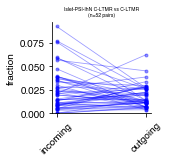

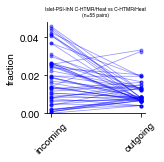

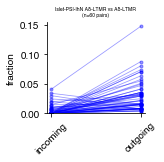

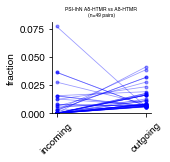

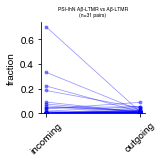

In [7]:
import matplotlib.pyplot as plt

for panel, ihn, sensory, title in PANELS:
    outgoing, incoming = results[panel]

    fig, ax = plt.subplots(figsize=(6 * CM, 6 * CM))
    for f_in, f_out in zip(incoming, outgoing):
        ax.plot([0, 1], [f_in, f_out], color="blue", alpha=0.4,
                marker="o", markersize=3, linewidth=0.8)

    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["incoming", "outgoing"], rotation=45)
    ax.set_ylabel("fraction")
    ax.set_title(f"{title}\n(n={len(outgoing)} pairs)", fontsize=5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"figureS9{panel}_{ihn}_vs_{sensory}.svg", format="svg",
                bbox_inches="tight")
    plt.show()


In [5]:
# Summary: no pair dominates either side, which is the point of the figure.
import numpy as np

print(f"{'panel':>6s} {'pairs':>6s} {'max incoming':>14s} {'max outgoing':>14s}"
      f" {'median in':>11s} {'median out':>11s}")
for panel, ihn, sensory, title in PANELS:
    out, inc = np.array(results[panel][0]), np.array(results[panel][1])
    print(f"{panel:>6s} {len(out):6d} {inc.max():13.1%} {out.max():14.1%}"
          f" {np.median(inc):10.1%} {np.median(out):11.1%}")


 panel  pairs   max incoming   max outgoing   median in  median out
     c     52          9.3%           6.2%       2.0%        1.3%
     d     55          4.6%           3.3%       1.6%        0.8%
     e     60          4.1%          14.8%       0.0%        1.9%
     f     49          7.7%           4.1%       0.0%        0.8%
     g     31         70.4%           8.9%       0.0%        0.9%


## One outlier worth knowing about

The summary above shows a single pair in panel **g** reaching 70.4% incoming, which looks
at odds with "a single sensory neuron contributed only a small fraction of a PSI-IhN's
total sensory input".

It is a denominator effect, not a real self-feedback pair: one `islet-abltmr` PSI-IhN has
only **27** sensory input synapses recorded on its dendrite, against 225–454 for the other
six in that population (and ~1,000–1,500 for the islet C-LTMR / C-HTMR/Heat cells). A
single 19-synapse afferent is 70% of 27. The cell below lists the per-neuron denominators
so this is visible rather than hidden.

Dropping that one PSI-IhN leaves the panel-g maximum at a few percent, in line with the
other four panels. It is shown as published; no filtering is applied.


In [6]:
# Sensory input recorded on each PSI-IhN dendrite -- the denominator of the
# "incoming" fraction. Small denominators inflate individual pairs.
print(psi_ihn.groupby("cell_type")["total_incoming"]
             .agg(["count", "min", "median", "max"]).to_string())

thin = psi_ihn[psi_ihn.total_incoming < 100]
if len(thin):
    print(f"\nPSI-IhNs with <100 sensory input synapses "
          f"(likely incompletely reconstructed dendrites):")
    print(thin[["cell_type", "dendrite_root_id", "total_incoming"]].to_string(index=False))


              count   min  median   max
cell_type                              
islet-abltmr      7    27   226.0   454
islet-adhtmr      6   290   326.5   402
islet-adltmr      5   206   367.0   419
islet-cltmr       5   926  1195.0  1512
islet-mrgd        5  1124  1319.0  1433

PSI-IhNs with <100 sensory input synapses (likely incompletely reconstructed dendrites):
   cell_type   dendrite_root_id  total_incoming
islet-abltmr 720575940937869229              27
islet-abltmr 720575940871523385              66
